In [1]:
import xarray as xr
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature 
from scipy import stats


In [2]:
# --- read netcdf file
dset = xr.open_dataset('../data/sst.mnmean.nc')   
sst = dset.sst.sel()
# sst =  xr.open_dataset('../data/sst.mnmean.nc')['sst']


In [3]:

#---------- Calculate climatology ----------
clim = sst.sel(time=slice('1982-01', '2022-12')).groupby('time.month').mean(dim='time')
print(clim) 

<xarray.DataArray 'sst' (month: 12, lat: 180, lon: 360)> Size: 3MB
array([[[-1.7900007, -1.7900007, -1.7900007, ..., -1.7900007,
         -1.7900007, -1.7900007],
        [-1.7900007, -1.7900007, -1.7900007, ..., -1.7900007,
         -1.7900007, -1.7900007],
        [-1.7834148, -1.7807319, -1.780244 , ..., -1.7892689,
         -1.7892689, -1.789025 ],
        ...,
        [-1.7900007, -1.7900007, -1.7900007, ..., -1.7900007,
         -1.7900007, -1.7900007],
        [-1.7900007, -1.7900007, -1.7900007, ..., -1.7900007,
         -1.7900007, -1.7900007],
        [-1.7900007, -1.7900007, -1.7900007, ..., -1.7900007,
         -1.7900007, -1.7900007]],

       [[-1.7900007, -1.7900007, -1.7900007, ..., -1.7900007,
         -1.7900007, -1.7900007],
        [-1.7900007, -1.7900007, -1.7900007, ..., -1.7900007,
         -1.7900007, -1.7900007],
        [-1.7860979, -1.7843906, -1.7841468, ..., -1.7900007,
         -1.7900007, -1.7900007],
...
        [-1.7900007, -1.7900007, -1.7900007, ..., 

In [4]:
#---------- Calculate anomalies ------------
# sst는 1981-12 ~ 2023-01 (분석기간 1982~2022의 앞뒤로 1개월씩 여유)
# 월별 아노말리 = 각 달의 값 - 같은 달의 기후값(clim, 1982~2022 기준)
anomt = sst.groupby('time.month') - clim

# 3개월 이동평균 (center=True: 해당 달 + 앞뒤 1개월 평균)
anom = anomt.rolling(time=3, center=True).mean()
print(anom['time'])


<xarray.DataArray 'time' (time: 494)> Size: 4kB
array(['1981-12-01T00:00:00.000000000', '1982-01-01T00:00:00.000000000',
       '1982-02-01T00:00:00.000000000', ..., '2022-11-01T00:00:00.000000000',
       '2022-12-01T00:00:00.000000000', '2023-01-01T00:00:00.000000000'],
      shape=(494,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 4kB 1981-12-01 1982-01-01 ... 2023-01-01
    month    (time) int64 4kB 12 1 2 3 4 5 6 7 8 9 10 ... 4 5 6 7 8 9 10 11 12 1
Attributes:
    long_name:        Time
    actual_range:     [66443. 81449.]
    delta_t:          0000-01-00 00:00:00
    avg_period:       0000-01-00 00:00:00
    prev_avg_period:  0000-00-07 00:00:00
    standard_name:    time
    axis:             T
    bounds:           time_bnds


In [5]:
#------------ Calculate DJF Nino index ---------
# 이전 시간의 다음의 두 코드를 한번에 실행할 수 있음 
# nino34area = anom.where((anom.lat < 5) & (anom.lat > -5) & (anom.lon > 190) & (anom.lon < 240), drop=True)
# nino34 = nino34area.mean(dim=['lat', 'lon'])        # 영역 평균 → (time,)

nino34 = anom.where((anom.lat<5) & (anom.lat>-5) & (anom.lon>190) & (anom.lon<240), drop=True).mean(dim=['lat','lon'])

In [6]:

ninos = nino34[1::12]  # 1981-12 부터 시작하므로 [1] = 1982-01 여기에서 12개월 간격으로 뽑으므로 DJF 
print(ninos['time'])
print(len(ninos)) 

<xarray.DataArray 'time' (time: 42)> Size: 336B
array(['1982-01-01T00:00:00.000000000', '1983-01-01T00:00:00.000000000',
       '1984-01-01T00:00:00.000000000', '1985-01-01T00:00:00.000000000',
       '1986-01-01T00:00:00.000000000', '1987-01-01T00:00:00.000000000',
       '1988-01-01T00:00:00.000000000', '1989-01-01T00:00:00.000000000',
       '1990-01-01T00:00:00.000000000', '1991-01-01T00:00:00.000000000',
       '1992-01-01T00:00:00.000000000', '1993-01-01T00:00:00.000000000',
       '1994-01-01T00:00:00.000000000', '1995-01-01T00:00:00.000000000',
       '1996-01-01T00:00:00.000000000', '1997-01-01T00:00:00.000000000',
       '1998-01-01T00:00:00.000000000', '1999-01-01T00:00:00.000000000',
       '2000-01-01T00:00:00.000000000', '2001-01-01T00:00:00.000000000',
       '2002-01-01T00:00:00.000000000', '2003-01-01T00:00:00.000000000',
       '2004-01-01T00:00:00.000000000', '2005-01-01T00:00:00.000000000',
       '2006-01-01T00:00:00.000000000', '2007-01-01T00:00:00.000000000',
   

In [7]:
# -- Composite El Nino years
# ninos는 42개(1982~2023년 1월)이고 마지막 2023-01은 NaN
# std는 NaN을 건너뛰고 계산됨 (xarray 기본값 skipna=True)
std = ninos.std(dim='time').values

# anom(494개월)과 ninos(42개, 매년 1월)는 time 길이가 다르지만,
# where는 두 자료의 공통 시점(매년 1월)만 자동으로 남김
# NaN > std 는 False이므로 2023-01은 선택되지 않음
compo = anom.where(ninos > std).mean(dim='time')

In [8]:
# -- Print El Nino years
# 연도는 DJF의 1월 기준 (예: 1998 = 1997/98 겨울)
elyr = ninos.where(ninos > std, drop=True)
print(elyr['time'].dt.year.values)

# # Advanced Option 1: Using Numpy
# dates = elyr.time.values.astype('datetime64[Y]').astype(int) + 1970
# print(dates)
# # Advanced Option 2: Using Pandas
# # import pandas as pd
# # print(pd.DatetimeIndex(elyr.time.values).year)

[1983 1987 1992 1998 2003 2010 2016]


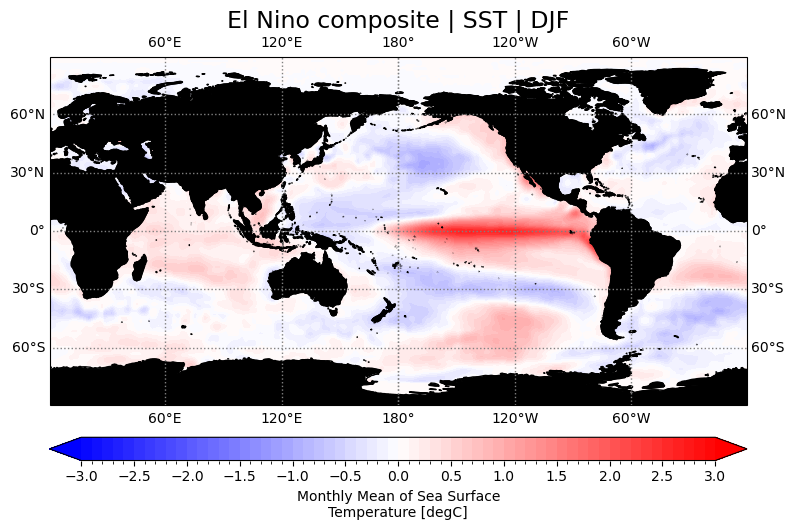

In [9]:
#------------------------- Plotting: Composite --------------------------
fig = plt.figure(figsize=(9, 7))                           # Figure setting
ax = plt.axes(projection=ccrs.PlateCarree(180))            # Axes setting

clevs = np.around(np.arange(-3, 3.1, 0.1), 1)              # 색 구간: 0.1 간격
# np.around(..., 1)로 소수점 첫째 자리까지 반올림해 깔끔한 값으로 정리
ticks = np.around(np.arange(-3, 3.1, 0.5), 1)              # 컬러바 눈금: 0.5 간격

# extend='both': ±3 밖의 값도 양 끝 색으로 칠함 (컬러바에도 삼각형 표시)
compo.plot.contourf(ax=ax, levels=clevs, cmap='bwr', extend='both',
                    transform=ccrs.PlateCarree(),
                    cbar_kwargs={'orientation': 'horizontal', 'pad': 0.06,
                                 'aspect': 30, 'ticks': ticks})

ax.set_title('El Nino composite | SST | DJF', fontsize=17)
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, linestyle=':', color='gray')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                            edgecolor='face', facecolor='black'))

plt.savefig('el_nino_composite_sst_djf.png', bbox_inches='tight')
plt.show()



In [10]:

#------------------- Significance test for Composite -------------------
# where는 anom과 ninos의 공통 시점(매년 1월, 42개)만 남김
#   sample1: 엘니뇨 해만 값, 나머지는 NaN
#   sample2: 엘니뇨가 아닌 해만 값, 나머지는 NaN
#   (2023-01은 ninos가 NaN이라 양쪽 모두에서 제외)
sample1 = anom.where(ninos > std)
sample2 = anom.where(ninos <= std)

In [11]:

# 각 표본에 실제로 값이 있는 연도 확인 (전부 NaN인 해만 제외)
yr1 = sample1.dropna(dim='time', how='all')['time'].dt.year.values
yr2 = sample2.dropna(dim='time', how='all')['time'].dt.year.values
print('엘니뇨 해   :', yr1, len(yr1))   # 7개: 1983 1987 1992 1998 2003 2010 2016
print('그 외의 해  :', yr2, len(yr2))   # 34개 

엘니뇨 해   : [1983 1987 1992 1998 2003 2010 2016] 7
그 외의 해  : [1982 1984 1985 1986 1988 1989 1990 1991 1993 1994 1995 1996 1997 1999
 2000 2001 2002 2004 2005 2006 2007 2008 2009 2011 2012 2013 2014 2015
 2017 2018 2019 2020 2021 2022] 34


In [12]:

# t-검정 (equal_var=False: 두 그룹의 분산이 같다고 가정하지 않음)
# nan_policy='omit': 위에서 생긴 NaN을 건너뛰고 계산
# axis=0: 첫 번째 차원(time) 방향으로 검정 — anom이 (time, lat, lon) 순서일 때만 맞음
tval, pval = stats.ttest_ind(sample1, sample2, axis=0,
                             equal_var=False, nan_policy='omit',
                             alternative='two-sided')

/home/jsp/anaconda3/envs/climstat/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:660: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return result_to_tuple(hypotest_fun_out(*samples, **kwds), n_out)


In [13]:
composig = compo.where(pval < 0.05)                        # 유의한 격자만 남김

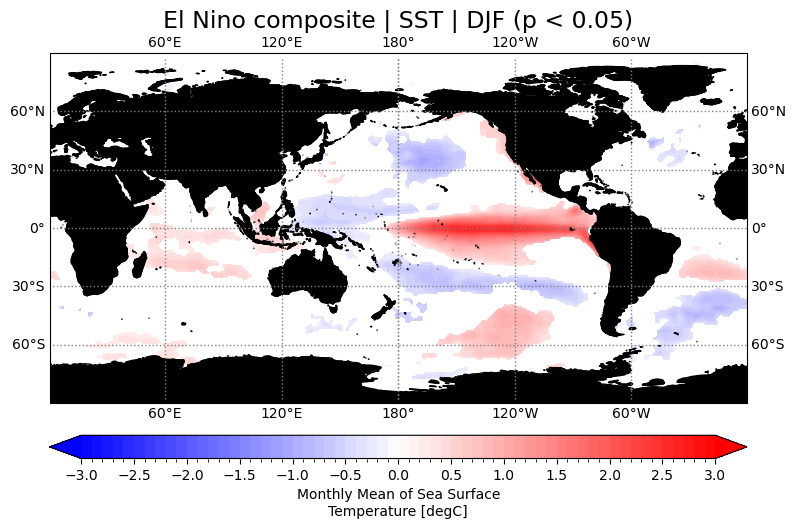

In [14]:
#------------------ Plotting: Significant region only ------------------
fig = plt.figure(figsize=(9, 7))
ax = plt.axes(projection=ccrs.PlateCarree(180))
composig.plot.contourf(ax=ax, levels=clevs, cmap='bwr', extend='both',
                       transform=ccrs.PlateCarree(),
                       cbar_kwargs={'orientation': 'horizontal', 'pad': 0.06,
                                    'aspect': 30, 'ticks': ticks})

# (선택) 전체 composite 위에 유의 영역을 등고선으로 표시하는 방법
# lons = compo['lon']
# lats = compo['lat']
# ax.contour(lons, lats, pval, levels=[0.01, 0.05],
#            colors=['darkred', 'red'], transform=ccrs.PlateCarree())

ax.set_title('El Nino composite | SST | DJF (p < 0.05)', fontsize=17)
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, linestyle=':', color='gray')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                            edgecolor='face', facecolor='black'))

plt.savefig('el_nino_composite_sst_djf_sig.png', bbox_inches='tight')
plt.show()

In [15]:
data = pd.read_csv('../data/rn_20260928132312.csv', encoding='euc-kr', skiprows=7)
data.head()

,년월,지점,강수량(mm)
0,1980-01,146,37.1
1,1980-02,146,16.1
2,1980-03,146,63.4
3,1980-04,146,138.3
4,1980-05,146,116.7


In [16]:

#--------- Make a new Pandas Dataframe ----------
dates = pd.DatetimeIndex(data['년월'])  # set 'time' as date
precip = data['강수량(mm)']             # select precip data

In [17]:

pdata1 = pd.DataFrame({'time': dates, '강수량(mm)': precip}) 
pdata2 = pdata1.set_index(['time'])    # Set 'time' as index

In [18]:
# pandas → xarray: 기본적으로 변수 '강수량(mm)'이 들어 있는 Dataset(상자)이 됨
print(pdata2.to_xarray())

# 2. .to_array(): 상자 안 변수를 꺼내 sst처럼 익숙한 DataArray로 만듦
print(pdata2.to_xarray().to_array())          # (variable: 1, time: N)

# 그런데 변수를 쌓는 차원(variable)이 새로 생겨서 axis=0이 variable이 됨
print(pdata2.to_xarray().to_array().shape)    # (1, N)

<xarray.Dataset> Size: 9kB
Dimensions:  (time: 552)
Coordinates:
  * time     (time) datetime64[us] 4kB 1980-01-01 1980-02-01 ... 2025-12-01
Data variables:
    강수량(mm)  (time) float64 4kB 37.1 16.1 63.4 138.3 ... 465.0 112.5 27.6 29.5
<xarray.DataArray (variable: 1, time: 552)> Size: 4kB
array([[ 37.1,  16.1,  63.4, 138.3, 116.7, 213.2, 383.4, 240.2,  35.4,
         91.7,  34.3,  56.3,  36.6,  36.5,  20.8,  58.7,  58.2,  95.7,
        338.9, 474.7, 111.1,  74.9,  18.4,  17.4,  20.1,  10.8,  60.1,
         59.6, 146.5,  33.1, 129.7, 227.2,   2.3,  68.6, 127. ,  49.2,
         23.2,  52.7,  72.2, 134.1,  60.2, 174.9, 246.3, 160.1, 156.9,
         53.4,  51.3,   8.9,   8.7,  17.7,  22.6, 175.9,  98.9, 152.6,
        426. , 145.8, 314.6,  61. ,  55.8,  17.5,  20.8,  43.8,  86.7,
         62.7, 142.2, 155.3, 346.7, 273.3, 319.7, 112.6, 125.8,  42.4,
         17.6,  15.2,  59. ,  40.5, 172.5, 285.1, 165.3, 214.2, 128.1,
        101.4,  37.3,  69.7,  73.3,  60.5,  48. ,  59.5,  90.5, 123.8,


In [19]:
#------ Convert Pandas Dataframe to xarray -----
# [0, :]: variable 방향 0번째(강수량), time은 전부 → 1차원 시계열
pr = pdata2.to_xarray().to_array()[0, :]
print(pr.shape)                               # (N,)

(552,)


In [20]:
#------ Calculate climatology -----
pr_clim = pr.sel(time=slice('1980-01','2022-12')).groupby('time.month').mean(dim='time')   

#---------- Calculate anomalies ------------
pranom = pr.groupby('time.month') - pr_clim
print(pranom)

<xarray.DataArray (time: 552)> Size: 4kB
array([ 6.77674419e+00, -2.03883721e+01,  6.91627907e+00,  5.93511628e+01,
        2.93279070e+01,  5.69534884e+01,  8.73395349e+01, -4.26930233e+01,
       -9.36395349e+01,  3.39139535e+01, -1.95581395e+01,  2.40651163e+01,
        6.27674419e+00,  1.16279070e-02, -3.56837209e+01, -2.02488372e+01,
       -2.91720930e+01, -6.05465116e+01,  4.28395349e+01,  1.91806977e+02,
       -1.79395349e+01,  1.71139535e+01, -3.54581395e+01, -1.48348837e+01,
       -1.02232558e+01, -2.56883721e+01,  3.61627907e+00, -1.93488372e+01,
        5.91279070e+01, -1.23146512e+02, -1.66360465e+02, -5.56930233e+01,
       -1.26739535e+02,  1.08139535e+01,  7.31418605e+01,  1.69651163e+01,
       -7.12325581e+00,  1.62116279e+01,  1.57162791e+01,  5.51511628e+01,
       -2.71720930e+01,  1.86534884e+01, -4.97604651e+01, -1.22793023e+02,
        2.78604651e+01, -4.38604651e+00, -2.55813953e+00, -2.33348837e+01,
       -2.16232558e+01, -1.87883721e+01, -3.38837209e+01,  

In [21]:
print(pranom[23])

<xarray.DataArray ()> Size: 8B
array(-14.83488372)
Coordinates:
    time      datetime64[us] 8B 1981-12-01
    variable  <U7 28B '강수량(mm)'
    month     int64 8B 12


In [22]:

#------ Select December data -----
pr_dec = pranom[23::12]     # from 1981-12, Dec data only 

prstd = pr_dec.std().values

In [23]:
######################  Map data for composite ########################  
# ----------- read netcdf file  ------------
# --- read netcdf file
dset = xr.open_dataset('../data/sst.mnmean.nc')   
sst = dset.sst.sel()
# sst = dset['sst']
#---------- Calculate December sst climatology ----------
clim = sst.sel(time=slice('1981-12', '2022-12')).groupby('time.month').mean(dim='time')

#---- Calculate anomalies and select DEC data ---
anom = (sst.groupby('time.month') - clim)[0::12,:,:]

In [ ]:

#########################  Composite  ########################### 
#-------- Composite Jeonju precip years ---------
compo = anom.where(pr>prstd).mean(dim='time')

# -- Significant test for Composite
sample1 = anom.where(pr>prstd)
sample2 = anom.where(pr<=prstd)
tval, pval = stats.ttest_ind(sample1, sample2, axis=0, equal_var=False, nan_policy='omit', alternative='two-sided')

/home/jsp/anaconda3/envs/climstat/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:660: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return result_to_tuple(hypotest_fun_out(*samples, **kwds), n_out)


In [ ]:
##########################  Plotting  ############################
# ----------- Set plot  ------------
fig = plt.figure(figsize=(9,7))   # Figure 
ax = plt.axes(projection = ccrs.PlateCarree(180))   # Axes 

# ----------- Plot  ------------
clevs=np.around(np.arange(-1.5, 1.6, 0.1), 1)
ticks=np.around(np.arange(-1.5, 1.6, 0.5), 1)

compo.plot.imshow(ax=ax, levels = clevs, cmap='bwr', transform=ccrs.PlateCarree(),
                           cbar_kwargs={'orientation': 'horizontal', 'extend':'neither',
                           'pad': 0.06, 'aspect': 30, 'ticks': ticks}) 
# (선택) 전체 composite 위에 유의 영역을 등고선으로 표시하는 방법
# lons = compo['lon']
# lats = compo['lat']
# ax.contour(lons, lats, pval, levels=[0.01, 0.05],
#            colors=['darkred', 'red'], transform=ccrs.PlateCarree())
# ----------- Set Axes properties  ------------
ax.set_title('Jeonju High-precip composite | SST | December', fontsize=17)
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, linestyle=':', color='gray')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))

plt.savefig('jeonju_precip_composite_sst_dec.png')
plt.show()
